# Lab Notebook: Similarity, Density Estimation, and Itemset Mining

**Student Copy**

Fill in every `TODO` before running the cell. Blanks are marked with `______`.

## Section 0 -- Imports

Run this cell first.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import euclidean, cityblock, mahalanobis
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KernelDensity

---
## Section 1 -- Similarity and Distance

### 1a -- What Makes a Metric?

A function d(x, y) is a valid distance metric if it satisfies four properties:

1. **Non-negativity**: d(x, y) >= 0
2. **Coincidence**: d(x, y) = 0 if and only if x = y
3. **Symmetry**: d(x, y) = d(y, x)
4. **Triangle inequality**: d(x, z) <= d(x, y) + d(y, z)

Similarity and distance are related. One common conversion:

    Similarity = 1 / (1 + Distance)

### 1b -- Euclidean and Manhattan Distance

Euclidean (manual): 5.0
Euclidean (scipy):  5.0
Manhattan (manual): 7.0
Manhattan (scipy):  7.0


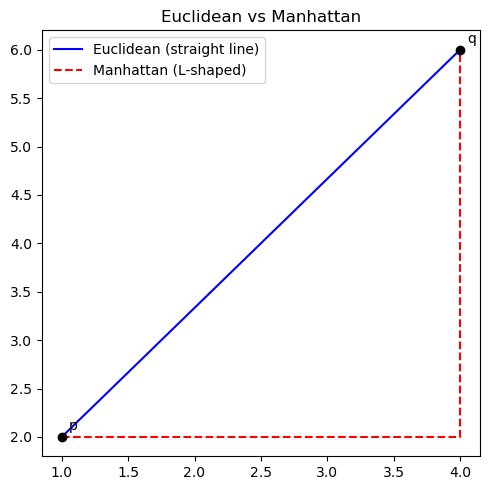

In [3]:
p = np.array([1.0, 2.0])
q = np.array([4.0, 6.0])

# TODO: Euclidean distance -- sqrt of sum of squared differences
eucl_manual = np.sqrt(np.sum((p-q) ** 2))
print("Euclidean (manual):", eucl_manual)
print("Euclidean (scipy): ", euclidean(p, q))

# TODO: Manhattan distance -- sum of absolute differences
manh_manual =np.sum(np.abs(p-q))
print("Manhattan (manual):", manh_manual)
print("Manhattan (scipy): ", cityblock(p, q))

# Visualization -- run once your distances are computed above
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([p[0], q[0]], [p[1], q[1]], 'b-', label='Euclidean (straight line)')
ax.plot([p[0], q[0], q[0]], [p[1], p[1], q[1]], 'r--', label='Manhattan (L-shaped)')
ax.scatter([p[0], q[0]], [p[1], q[1]], c='k', zorder=5)
ax.annotate('p', p, textcoords="offset points", xytext=(5, 5))
ax.annotate('q', q, textcoords="offset points", xytext=(5, 5))
ax.set_title("Euclidean vs Manhattan")
ax.legend()
plt.tight_layout()
plt.show()

### 1c -- Normalized Euclidean and Mahalanobis Distance

In [7]:
a = np.array([1.0, 100.0])
b = np.array([2.0, 105.0])

data_2d = np.array([[1, 100], [2, 102], [1.5, 98], [3, 110], [2, 105]], dtype=float)
# std along axis=0: one value per column (per feature)
stds = data_2d.std(axis=0)
# np.cov expects features as rows; data has shape (5,2) so pass data_2d.T
cov  = np.cov(data_2d.T)

# Euclidean (given for reference)
eucl = np.sqrt(np.sum((a - b) ** 2))
print("Euclidean:            ", round(eucl, 4))

# TODO: Normalized Euclidean
# Divide each element of (a - b) by the corresponding element of stds, then apply Euclidean formula
norm_eucl = eucl / np.sqrt(len(a))
print("Normalized Euclidean: ", round(norm_eucl, 4))

# TODO: Mahalanobis (manual)
# diff = a - b
# maha = sqrt( diff @ inv(cov) @ diff )
# Use np.linalg.inv() for the inverse and @ for matrix multiplication
diff = a - b
maha_manual = np.sqrt( diff @ np.linalg.inv(cov) @ diff )
maha_scipy  = mahalanobis(a, b, np.linalg.inv(cov))
print("Mahalanobis (manual):", round(maha_manual, 4))
print("Mahalanobis (scipy): ", round(maha_scipy, 4))

Euclidean:             5.099
Normalized Euclidean:  3.6056
Mahalanobis (manual): 1.3884
Mahalanobis (scipy):  1.3884


### 1d -- Cosine Similarity

cos_sim(v1, v2): 0.995  -- nearly identical direction
cos_sim(v1, v3): 0.0  -- orthogonal
cos_sim(v1, v4): -1.0  -- opposite directions


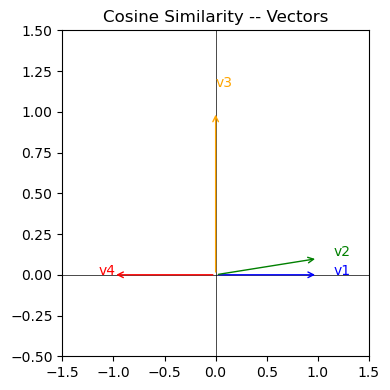

In [9]:
# TODO: Complete the function
# Formula: dot(u, v) / (norm(u) * norm(v))
# np.dot() for dot product, np.linalg.norm() for vector length
def cosine_sim(u, v):
    return np.dot(u,v) / (np.linalg.norm(u) * np.linalg.norm(v))

v1 = np.array([1, 0])
v2 = np.array([1, 0.1])
v3 = np.array([0, 1])
v4 = np.array([-1, 0])

print("cos_sim(v1, v2):", round(cosine_sim(v1, v2), 4), " -- nearly identical direction")
print("cos_sim(v1, v3):", round(cosine_sim(v1, v3), 4), " -- orthogonal")
print("cos_sim(v1, v4):", round(cosine_sim(v1, v4), 4), " -- opposite directions")

fig, ax = plt.subplots(figsize=(4, 4))
origin = [0, 0]
for vec, label, col in [(v1,'v1','b'), (v2,'v2','g'), (v3,'v3','orange'), (v4,'v4','r')]:
    ax.annotate("", xy=vec, xytext=origin, arrowprops=dict(arrowstyle="->", color=col))
    ax.text(vec[0]*1.15, vec[1]*1.15, label, color=col)
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
ax.set_title("Cosine Similarity -- Vectors")
plt.tight_layout()
plt.show()

### 1e -- Jaccard Similarity (Sets)

In [10]:
A = {'action', 'comedy', 'drama', 'thriller', 'romance'}
B = {'horror', 'sci-fi', 'animation', 'documentary'}
C = {'action', 'comedy', 'drama'}
D = {'drama', 'thriller', 'romance', 'horror', 'mystery'}

# TODO: Complete the function
# set1 & set2 gives the intersection; set1 | set2 gives the union
# Jaccard = |intersection| / |union|
def jaccard(set1, set2):
    return len(set1 & set2) / len(set1 | set2)

print("Jaccard(A, B):", round(jaccard(A, B), 4))
print("Jaccard(A, C):", round(jaccard(A, C), 4))
print("Jaccard(A, D):", round(jaccard(A, D), 4))

Jaccard(A, B): 0.0
Jaccard(A, C): 0.6
Jaccard(A, D): 0.4286


### 1f -- Bhattacharyya Coefficient (Distributions)

In [11]:
customers = {
    'A': np.array([0.4, 0.2, 0.1, 0.2, 0.1]),
    'B': np.array([0.3, 0.3, 0.1, 0.2, 0.1]),
    'C': np.array([0.1, 0.1, 0.5, 0.1, 0.2]),
    'D': np.array([0.4, 0.2, 0.1, 0.2, 0.1]),
}

# TODO: Complete the function
# BC = sum( sqrt(p * q) ) -- element-wise sqrt then sum
# BD = -log(BC)
def bhattacharyya(p, q):
    bc = np.sum(np.sqrt(p * q) )
    bd = -np.log(bc)
    return bc, bd

for pair in [('A','B'), ('A','C'), ('A','D')]:
    bc, bd = bhattacharyya(customers[pair[0]], customers[pair[1]])
    print(f"BC({pair[0]},{pair[1]}) = {bc:.4f}   BD = {bd:.4f}")

BC(A,B) = 0.9914   BD = 0.0087
BC(A,C) = 0.8479   BD = 0.1650
BC(A,D) = 1.0000   BD = -0.0000


---
## Section 2 -- Density Estimation

### 2a -- The Problem with Histograms

Run the cell below and look at the two plots. The same 20 data points produce two very different-looking histograms depending on where the bins start.

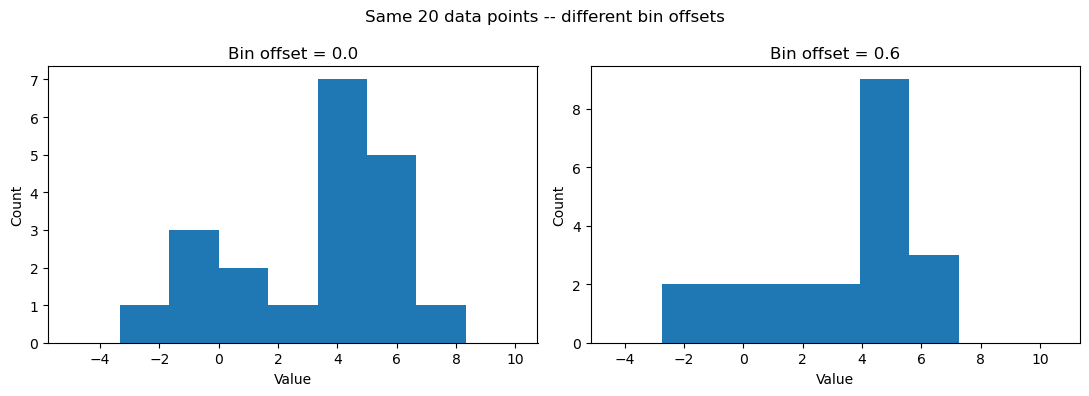

In [12]:
def make_data(N, f=0.3, rseed=1):
    # Creates a bimodal 1D dataset: ~30% near 0, ~70% near 5
    rand = np.random.RandomState(rseed)
    x = rand.randn(N)
    x[int(f * N):] += 5
    return x

x_small = make_data(20)
bins = np.linspace(-5, 10, 10)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for i, offset in enumerate([0.0, 0.6]):
    ax[i].hist(x_small, bins=bins + offset)   #TODO : plot the histogram with bins
    ax[i].set_title(f"Bin offset = {offset}")
    ax[i].set_xlabel("Value")
    ax[i].set_ylabel("Count")
plt.suptitle("Same 20 data points -- different bin offsets")
plt.tight_layout()
plt.show()

### 2b -- Parametric Density: Gaussian Mixture Model (GMM)

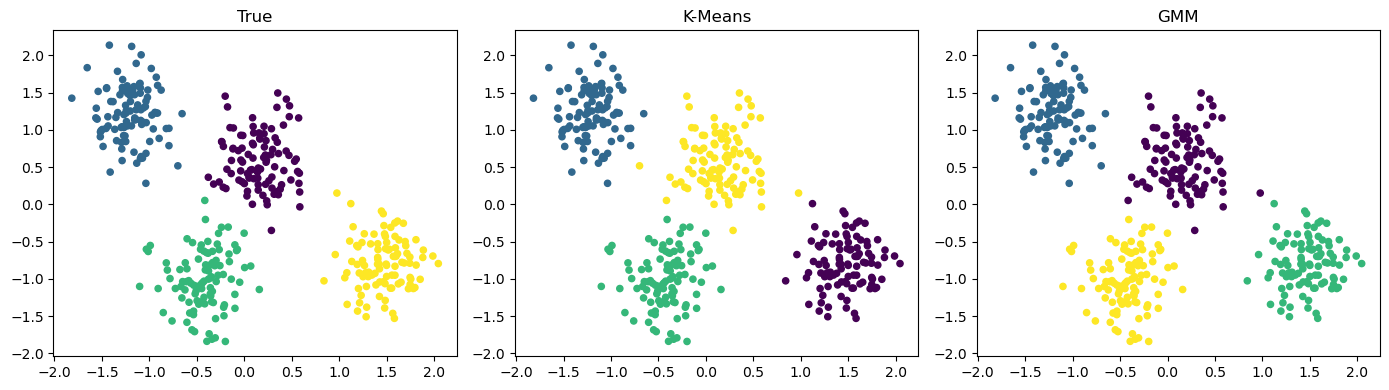

In [15]:
X, y_true = make_blobs(n_samples=400, centers=4, cluster_std=0.60, random_state=0)
X = X[:, ::-1]
X = (X - X.mean(axis=0)) / X.std(axis=0)

# TODO: Create a KMeans model with n_clusters=4, random_state=0
# Then fit it on X and predict labels
kmeans = KMeans(n_clusters=4, random_state=0)
kmeans.fit(X)
km_labels = kmeans.predict(X)

# TODO: Create a GaussianMixture with n_components=4, covariance_type='full', random_state=42
# Then fit it on X and predict labels
gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
gmm.fit(X)
gmm_labels = gmm.predict(X)

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for a, labels, title in zip(ax, [y_true, km_labels, gmm_labels], ['True', 'K-Means', 'GMM']):
    a.scatter(X[:, 0], X[:, 1], c=labels, s=20, cmap='viridis')
    a.set_title(title)
plt.tight_layout()
plt.show()

In [17]:
# GMM also returns log-probabilities for each point, not just labels
# TODO: call gmm.score_samples(X) and store the result as log_probs
log_probs = gmm.score_samples(X)
print("log P(x) for first 5 points:", log_probs[:5].round(3))
# Exponentiate to recover the actual probability density values
print("P(x) for first 5 points:    ", np.exp(log_probs[:5]).round(5))
print()
# TODO: print gmm.means_ (mean of each component) and gmm.covariances_ (covariance of each component)
# Note: gmm.covariances_ is the same Sigma matrix used in the Mahalanobis formula
print("Component means:")
print(gmm.means_)
print()
print("Component covariances:")
for i, cov in enumerate(gmm.covariances_):
    print(f"  Component {i}:")
    print(f"    {cov.round(3)}")

log P(x) for first 5 points: [-6.381 -2.444 -3.131 -0.909 -2.139]
P(x) for first 5 points:     [0.00169 0.08682 0.04368 0.40302 0.11779]

Component means:
[[ 0.15864912  0.57535743]
 [-1.20006185  1.21497383]
 [ 1.4678002  -0.79984333]
 [-0.42706917 -1.017157  ]]

Component covariances:
  Component 0:
    [[ 0.061 -0.001]
 [-0.001  0.143]]
  Component 1:
    [[ 0.044 -0.006]
 [-0.006  0.132]]
  Component 2:
    [[0.054 0.004]
 [0.004 0.111]]
  Component 3:
    [[0.057 0.007]
 [0.007 0.145]]


#### GMM on Stretched Data

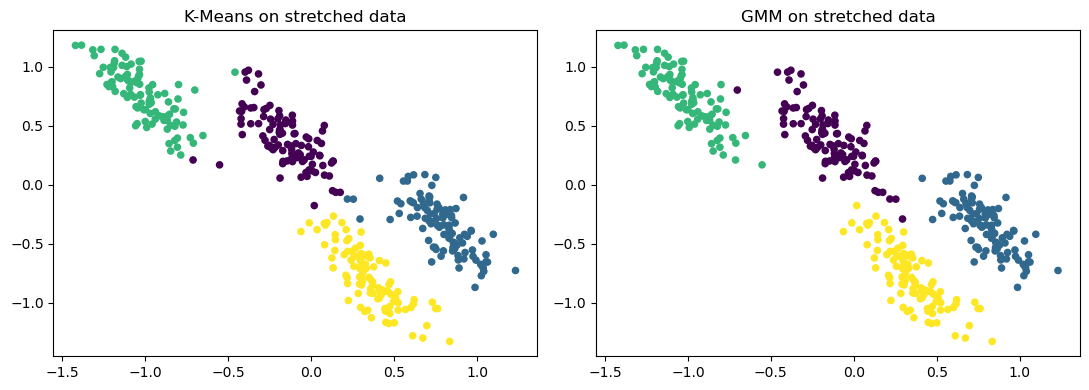

In [18]:
rng = np.random.RandomState(13)
X_stretched = np.dot(X, rng.randn(2, 2))

# TODO: Fit KMeans (n_clusters=4) and GaussianMixture (n_components=4, covariance_type='full')
# on X_stretched
kmeans_s = KMeans(n_clusters=4)
kmeans_s.fit(X_stretched)

gmm_s = GaussianMixture(n_components=4, covariance_type='full')
gmm_s.fit(X_stretched)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(X_stretched[:,0], X_stretched[:,1], c=kmeans_s.labels_, s=20, cmap='viridis')
ax[0].set_title("K-Means on stretched data")
ax[1].scatter(X_stretched[:,0], X_stretched[:,1], c=gmm_s.predict(X_stretched), s=20, cmap='viridis')
ax[1].set_title("GMM on stretched data")
plt.tight_layout()
plt.show()

#### Custom 3-Component Dataset

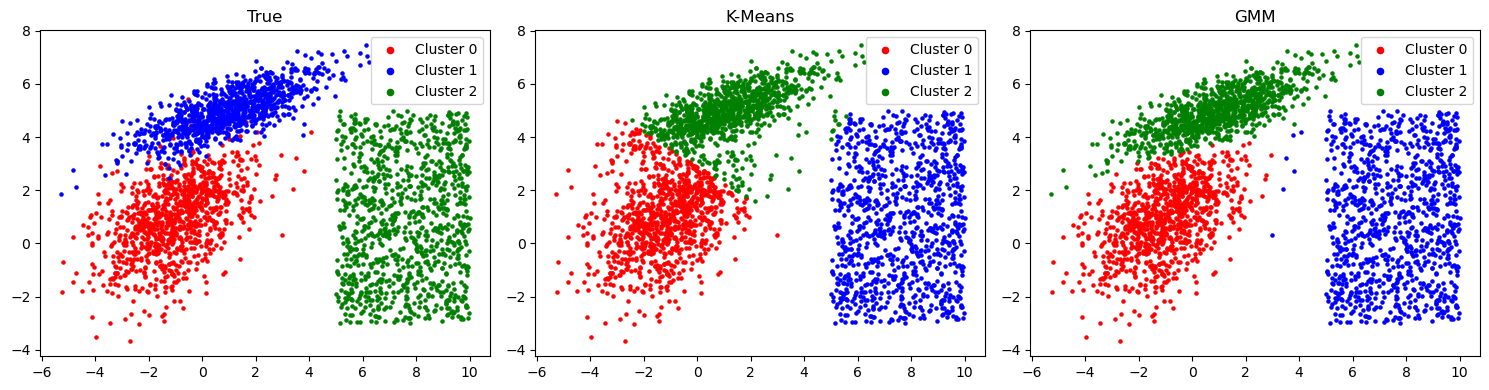

In [19]:
def create_dataset(n_samples=3000):
    n = n_samples // 3
    d0 = np.random.multivariate_normal([-1, 1], [[2, 1],[1, 2]], n)
    d1 = np.random.multivariate_normal([1, 5],  [[3, 1],[2, 1]], n)
    d2 = np.random.uniform([5, -3], [10, 5], (n, 2))
    X_all = np.vstack([d0, d1, d2])
    y_all = np.array([0]*n + [1]*n + [2]*n)
    return X_all, y_all

X3, y3 = create_dataset()

# TODO: Fit a GaussianMixture (n_components=3, init_params='kmeans') and
# a KMeans (n_clusters=3) on X3
gm3 = GaussianMixture(n_components=3, init_params='kmeans')
gm3.fit(X3)

km3 = KMeans(n_clusters=3)
km3.fit(X3)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, labels, title in zip(ax, [y3, km3.labels_, gm3.predict(X3)], ['True', 'K-Means', 'GMM']):
    for c, col in [(0,'r'),(1,'b'),(2,'g')]:
        pts = X3[labels==c]
        a.scatter(pts[:,0], pts[:,1], c=col, s=5, label=f"Cluster {c}")
    a.set_title(title)
    a.legend(markerscale=2)
plt.tight_layout()
plt.show()

### 2c -- Univariate GMM

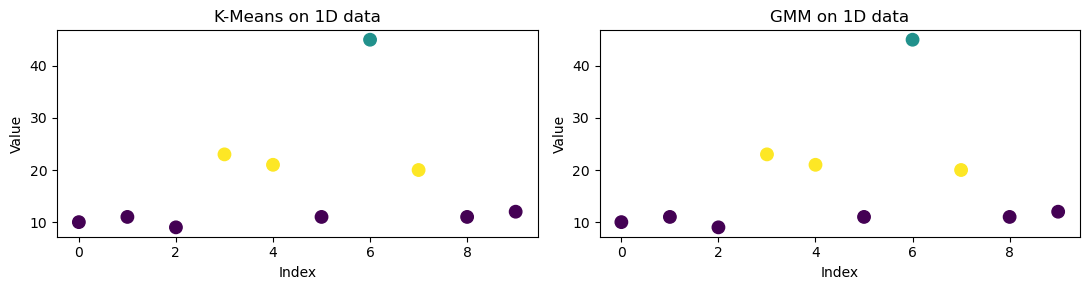

In [21]:
data_1d = np.array([10, 11, 9, 23, 21, 11, 45, 20, 11, 12])

# reshape(-1, 1) turns a 1D array into a 2D column -- sklearn requires 2D input
# TODO: Fit KMeans (n_clusters=3) and get labels
km_1d = KMeans(n_clusters=3)
km_labels_1d = km_1d.fit_predict(data_1d.reshape(-1, 1))

# TODO: Fit GaussianMixture (n_components=3) and get labels
gmm_1d = GaussianMixture(n_components=3)
gmm_1d.fit(data_1d.reshape(-1, 1))
gmm_labels_1d = gmm_1d.predict(data_1d.reshape(-1, 1))

fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].scatter(range(len(data_1d)), data_1d, c=km_labels_1d, cmap='viridis', s=80)
ax[0].set_title("K-Means on 1D data")
ax[1].scatter(range(len(data_1d)), data_1d, c=gmm_labels_1d, cmap='viridis', s=80)
ax[1].set_title("GMM on 1D data")
for a in ax:
    a.set_xlabel("Index")
    a.set_ylabel("Value")
plt.tight_layout()
plt.show()

### 2d -- Nonparametric Density: Kernel Density Estimation (KDE)

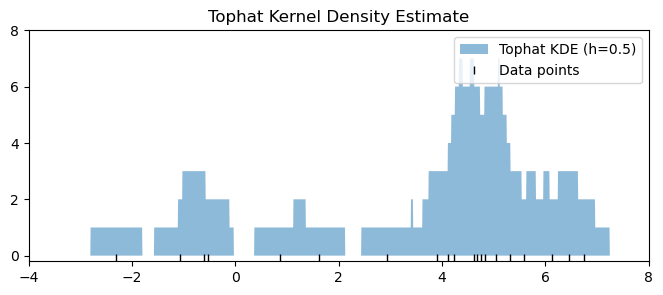

In [25]:
x_kde  = make_data(20)
x_eval = np.linspace(-4, 8, 2000)

# TODO: Tophat KDE by hand
# For each xi in x_kde, add a boolean array (np.abs(x_eval - xi) < 0.5) to the running sum
# Hint: use Python's built-in sum() with a generator: sum(... for xi in x_kde)
density_tophat = sum(np.abs(x_eval - xi) < 0.5 for xi in x_kde )

plt.figure(figsize=(8, 3))
plt.fill_between(x_eval, density_tophat, alpha=0.5, label='Tophat KDE (h=0.5)')
# np.full_like creates an array of the same shape as x_kde filled with -0.1
# this places tick marks just below the x-axis to show data point locations
plt.plot(x_kde, np.full_like(x_kde, -0.1), '|k', markeredgewidth=1, label='Data points')
plt.title("Tophat Kernel Density Estimate")
plt.legend()
plt.axis([-4, 8, -0.2, 8])
plt.show()

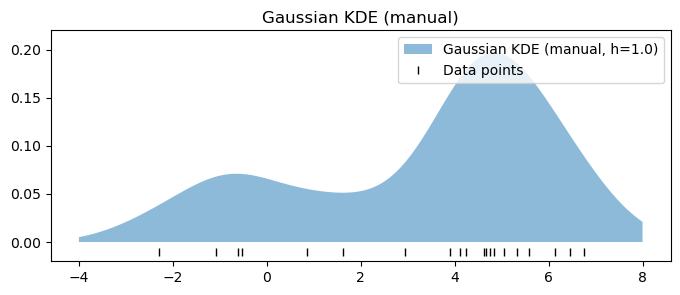

In [28]:
# Gaussian kernel formula for a single xi:
#   (1 / (sqrt(2*pi) * bandwidth)) * exp( -0.5 * ((x_eval - xi) / bandwidth)^2 )
# Sum this over all xi, then divide by len(x_kde)

bandwidth = 1.0

# TODO: Compute density_gauss using the formula above in a generator passed to sum()
density_gauss = sum((1 / (np.sqrt(2*np.pi) * bandwidth)) * np.exp( -0.5 * ((x_eval - xi) / bandwidth)**2 ) for xi in x_kde) / len(x_kde)

plt.figure(figsize=(8, 3))
plt.fill_between(x_eval, density_gauss, alpha=0.5, label='Gaussian KDE (manual, h=1.0)')
plt.plot(x_kde, np.full_like(x_kde, -0.01), '|k', markeredgewidth=1, label='Data points')
plt.ylim([-0.02, 0.22])
plt.title("Gaussian KDE (manual)")
plt.legend()
plt.show()

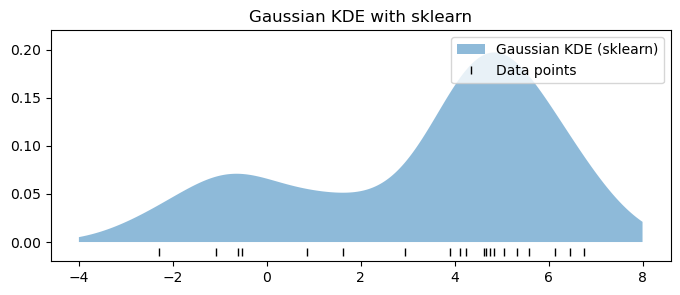

In [30]:
# Now use sklearn KernelDensity -- the result should match your manual version above
# Input to fit() and score_samples() must be 2D: use x[:, None] to reshape

# TODO: Create KernelDensity with bandwidth=1.0, kernel='gaussian'
kde_sk = KernelDensity(bandwidth=1.0, kernel='gaussian')

# TODO: Fit on x_kde (use x_kde[:, None] to make it 2D)
kde_sk.fit(x_kde[:, None] )

# TODO: Call score_samples on x_eval (use x_eval[:, None]) and store as log_dens
log_dens = kde_sk.score_samples(x_eval[:, None])

plt.figure(figsize=(8, 3))
# np.exp converts log-density back to density
plt.fill_between(x_eval, np.exp(log_dens), alpha=0.5, label='Gaussian KDE (sklearn)')
plt.plot(x_kde, np.full_like(x_kde, -0.01), '|k', markeredgewidth=1, label='Data points')
plt.ylim(-0.02, 0.22)
plt.title("Gaussian KDE with sklearn")
plt.legend()
plt.show()

#### Effect of Bandwidth

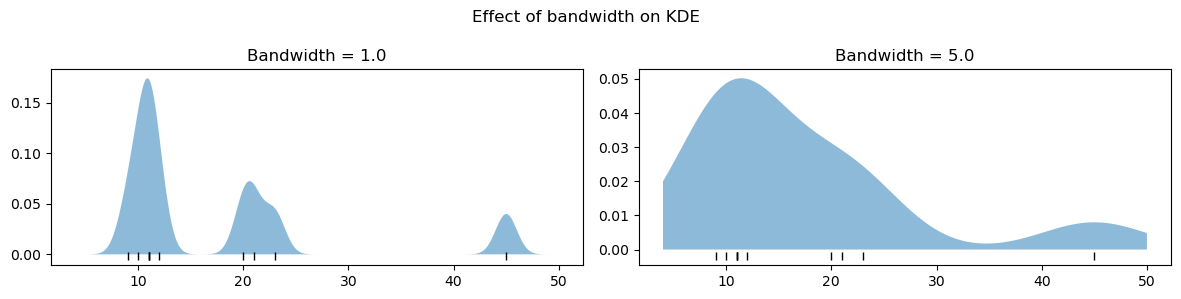

In [31]:
data_small = np.array([10,11,9,23,21,11,45,20,11,12], dtype=float)
x_range = np.linspace(data_small.min()-5, data_small.max()+5, 2000)

fig, ax = plt.subplots(1, 2, figsize=(12, 3))
for i, bw in enumerate([1.0, 5.0]):
    # TODO: For each bandwidth value, create and fit a KernelDensity, then call score_samples
    kde_bw = KernelDensity(bandwidth=bw, kernel = 'gaussian')
    kde_bw.fit(data_small[:, None])
    lp = kde_bw.score_samples(x_range[:, None])
    ax[i].fill_between(x_range, np.exp(lp), alpha=0.5)
    ax[i].plot(data_small, np.full_like(data_small, -0.002), '|k', markeredgewidth=1)
    ax[i].set_title(f"Bandwidth = {bw}")
plt.suptitle("Effect of bandwidth on KDE")
plt.tight_layout()
plt.show()

# TODO: Fill in the blanks based on what you see
# With bandwidth=1.0 the estimate is: ______
# With bandwidth=5.0 the estimate is: ______

### 2e -- KDE in 2D

Run this cell as-is and observe the density surface.

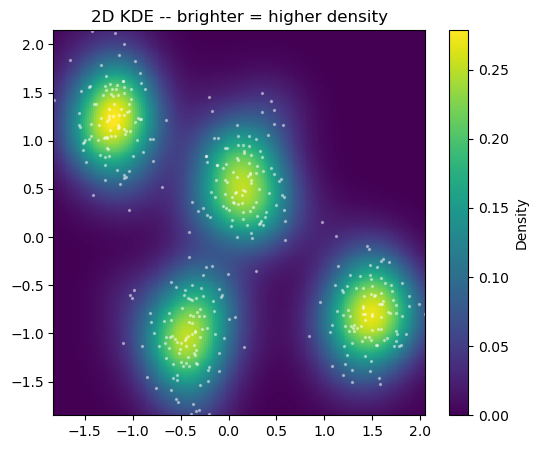

In [32]:
def kde2D(x, y, bandwidth, xbins=200j, ybins=200j):
    # Creates a grid of evaluation points and runs KDE over it
    xx, yy = np.mgrid[x.min():x.max():xbins, y.min():y.max():ybins]
    xy_sample = np.vstack([yy.ravel(), xx.ravel()]).T
    xy_train  = np.vstack([y, x]).T
    kde_skl = KernelDensity(bandwidth=bandwidth)
    kde_skl.fit(xy_train)
    z = np.exp(kde_skl.score_samples(xy_sample))
    return xx, yy, np.reshape(z, xx.shape)

xx, yy, zz = kde2D(X[:, 0], X[:, 1], bandwidth=0.25)
plt.figure(figsize=(6, 5))
# pcolormesh draws the density surface; brighter = more data in that region
plt.pcolormesh(xx, yy, zz, cmap='viridis')
plt.colorbar(label='Density')
plt.scatter(X[:, 0], X[:, 1], s=2, facecolor='white', alpha=0.4)
plt.title("2D KDE -- brighter = higher density")
plt.show()

---
## Section 3 -- Itemset Mining

### 3a -- Representing Transactions

In [33]:
transactions = [
    {'milk', 'bread', 'butter'},
    {'bread', 'eggs'},
    {'milk', 'bread', 'eggs', 'cheese'},
    {'milk', 'cheese'},
    {'bread', 'butter', 'eggs'},
    {'milk', 'bread', 'cheese', 'butter'},
    {'eggs', 'cheese'},
    {'milk', 'bread'},
    {'bread', 'eggs', 'butter'},
    {'milk', 'cheese', 'eggs'},
]

print(f"Number of transactions: {len(transactions)}")
for i, t in enumerate(transactions):
    print(f"  T{i+1}: {sorted(t)}")

Number of transactions: 10
  T1: ['bread', 'butter', 'milk']
  T2: ['bread', 'eggs']
  T3: ['bread', 'cheese', 'eggs', 'milk']
  T4: ['cheese', 'milk']
  T5: ['bread', 'butter', 'eggs']
  T6: ['bread', 'butter', 'cheese', 'milk']
  T7: ['cheese', 'eggs']
  T8: ['bread', 'milk']
  T9: ['bread', 'butter', 'eggs']
  T10: ['cheese', 'eggs', 'milk']


### 3b -- Support Counting

In [34]:
all_items = set(item for t in transactions for item in t)
min_support = 0.3
n = len(transactions)

# TODO: For each item, count how many transactions contain it and divide by n
# Store as item_support[item] = count / n
item_support = {}
for item in all_items:
    count = sum(1 for t in transactions if item in t)   # sum(1 for t in transactions if item in t)
    item_support[item] = count / n

print(f"Item support (threshold = {min_support}):")
for item, sup in sorted(item_support.items(), key=lambda x: -x[1]):
    flag = "" if sup >= min_support else "  [below threshold]"
    print(f"  {item}: {sup:.2f}{flag}")

# TODO: Build frequent_1 -- keep only items where support >= min_support
# Store as a set of frozensets: {frozenset([item]) for item, sup in ... if sup >= ...}
frequent_1 = {frozenset([item]) for item, sup in item_support.items() if sup >= min_support}
print(f"Frequent 1-itemsets: {[set(s) for s in frequent_1]}")

Item support (threshold = 0.3):
  bread: 0.70
  milk: 0.60
  eggs: 0.60
  cheese: 0.50
  butter: 0.40
Frequent 1-itemsets: [{'cheese'}, {'eggs'}, {'milk'}, {'bread'}, {'butter'}]


### 3c -- Candidate Generation (Apriori Trick)

In [35]:
from itertools import combinations

frequent_items_list = [list(s)[0] for s in frequent_1]
candidates_2 = [frozenset(pair) for pair in combinations(frequent_items_list, 2)]

# TODO: For each candidate pair, count how many transactions contain both items
# cand.issubset(t) checks if every item in cand appears in transaction t
support_2 = {}
for cand in candidates_2:
    count = sum(1 for t in transactions if cand.issubset(t))   # sum(1 for t in transactions if cand.issubset(t))
    support_2[cand] = count / n

print(f"2-itemset support (threshold = {min_support}):")
for itemset, sup in sorted(support_2.items(), key=lambda x: -x[1]):
    flag = "" if sup >= min_support else "  [below threshold]"
    print(f"  {set(itemset)}: {sup:.2f}{flag}")

frequent_2 = {k for k, v in support_2.items() if v >= min_support}

2-itemset support (threshold = 0.3):
  {'milk', 'cheese'}: 0.40
  {'eggs', 'bread'}: 0.40
  {'milk', 'bread'}: 0.40
  {'butter', 'bread'}: 0.40
  {'eggs', 'cheese'}: 0.30
  {'bread', 'cheese'}: 0.20  [below threshold]
  {'eggs', 'milk'}: 0.20  [below threshold]
  {'eggs', 'butter'}: 0.20  [below threshold]
  {'butter', 'milk'}: 0.20  [below threshold]
  {'butter', 'cheese'}: 0.10  [below threshold]


### 3d -- Association Rules

In [39]:
min_confidence = 0.5

print(f"Association rules (min confidence = {min_confidence}):")
print()

for itemset in frequent_2:
    items = list(itemset)
    for i in range(len(items)):
        antecedent = frozenset([items[i]])
        consequent = frozenset([items[1-i]])

        # TODO: confidence = support_2[itemset] / item_support[items[i]]
        conf = support_2[itemset] / item_support[items[i]]

        # TODO: jaccard = support_2[itemset] / (support(A) + support(B) - support_2[itemset])
        jac  = support_2[itemset] / (item_support[items[i]] + item_support[items[1-i]] - support_2[itemset])
        
        if conf >= min_confidence:
            print(f"  {set(antecedent)} -> {set(consequent)}")
            print(f"    confidence = {conf:.2f}   jaccard = {jac:.2f}")

Association rules (min confidence = 0.5):

  {'butter'} -> {'bread'}
    confidence = 1.00   jaccard = 0.57
  {'bread'} -> {'butter'}
    confidence = 0.57   jaccard = 0.57
  {'milk'} -> {'bread'}
    confidence = 0.67   jaccard = 0.44
  {'bread'} -> {'milk'}
    confidence = 0.57   jaccard = 0.44
  {'eggs'} -> {'bread'}
    confidence = 0.67   jaccard = 0.44
  {'bread'} -> {'eggs'}
    confidence = 0.57   jaccard = 0.44
  {'milk'} -> {'cheese'}
    confidence = 0.67   jaccard = 0.57
  {'cheese'} -> {'milk'}
    confidence = 0.80   jaccard = 0.57
  {'eggs'} -> {'cheese'}
    confidence = 0.50   jaccard = 0.37
  {'cheese'} -> {'eggs'}
    confidence = 0.60   jaccard = 0.37


---
## API Reference

All functions, classes, and attributes used in this notebook are listed below.
For each one the parameters are explained and an official documentation link is provided.

---

### numpy

**`np.sqrt(x)`**
Computes the square root of each element in x.
- `x` -- a number or array. Works element-wise on arrays.
- [numpy.sqrt docs](https://numpy.org/doc/stable/reference/generated/numpy.sqrt.html)

**`np.sum(a, axis=None)`**
Sums elements in array a.
- `a` -- input array
- `axis` -- which axis to sum along. `axis=0` sums down each column. Omitting it sums everything.
- [numpy.sum docs](https://numpy.org/doc/stable/reference/generated/numpy.sum.html)

**`np.abs(a)`**
Returns the absolute value of each element.
- `a` -- input array or scalar
- [numpy.absolute docs](https://numpy.org/doc/stable/reference/generated/numpy.absolute.html)

**`np.dot(u, v)`**
Dot product of two 1D arrays (sum of element-wise products).
- `u`, `v` -- arrays of the same length
- [numpy.dot docs](https://numpy.org/doc/stable/reference/generated/numpy.dot.html)

**`np.linalg.norm(v)`**
Euclidean length of a vector (square root of sum of squares).
- `v` -- 1D array
- [numpy.linalg.norm docs](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html)

**`np.linalg.inv(M)`**
Computes the inverse of a square matrix M such that M @ inv(M) = identity.
- `M` -- square 2D array
- [numpy.linalg.inv docs](https://numpy.org/doc/stable/reference/generated/numpy.linalg.inv.html)

**`np.cov(m)`**
Estimates the covariance matrix from data.
- `m` -- 2D array where each ROW is a variable and each COLUMN is an observation. If your data has shape (n_samples, n_features), pass `data.T`.
- [numpy.cov docs](https://numpy.org/doc/stable/reference/generated/numpy.cov.html)

**`np.linspace(start, stop, num)`**
Returns `num` evenly spaced values from `start` to `stop` inclusive.
- `start` -- first value
- `stop` -- last value
- `num` -- how many points to generate
- [numpy.linspace docs](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html)

**`np.exp(x)`**
Computes e raised to the power of each element. Used to undo log-probability (exponentiate log P(x) to get P(x)).
- `x` -- array or scalar
- [numpy.exp docs](https://numpy.org/doc/stable/reference/generated/numpy.exp.html)

**`np.log(x)`**
Natural logarithm (base e) of each element.
- `x` -- array or scalar, must be positive
- [numpy.log docs](https://numpy.org/doc/stable/reference/generated/numpy.log.html)

**`np.full_like(a, fill_value)`**
Creates an array of the same shape and type as `a`, filled with `fill_value`.
- `a` -- reference array (shape and dtype are copied)
- `fill_value` -- the value to fill with. We use -0.01 to place tick marks just below the x-axis.
- [numpy.full_like docs](https://numpy.org/doc/stable/reference/generated/numpy.full_like.html)

**`np.vstack([a, b])`**
Stacks arrays vertically (row by row). Combines two arrays into one with more rows.
- list of arrays -- each must have the same number of columns
- [numpy.vstack docs](https://numpy.org/doc/stable/reference/generated/numpy.vstack.html)

**`np.mgrid[a:b:nj, c:d:mj]`**
Creates a 2D mesh grid. `nj` and `mj` use imaginary numbers to specify the number of points (not step size).
- Used to create a dense grid of (x, y) evaluation points for 2D KDE.
- [numpy.mgrid docs](https://numpy.org/doc/stable/reference/generated/numpy.mgrid.html)

**`a.reshape(-1, 1)`**
Reshapes a 1D array of n elements into a 2D column vector of shape (n, 1).
- `-1` tells numpy to infer the dimension automatically.
- sklearn's fit and score_samples require 2D input, so 1D data must always be reshaped.
- [numpy.reshape docs](https://numpy.org/doc/stable/reference/generated/numpy.reshape.html)

**`a.ravel()`**
Flattens any array to 1D.
- No parameters needed.
- [numpy.ravel docs](https://numpy.org/doc/stable/reference/generated/numpy.ravel.html)

---

### scipy.spatial.distance

**`euclidean(u, v)`**
Euclidean distance between two points u and v.
- `u`, `v` -- 1D arrays of equal length
- [scipy euclidean docs](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.euclidean.html)

**`cityblock(u, v)`**
Manhattan (L1) distance between two points.
- `u`, `v` -- 1D arrays of equal length
- [scipy cityblock docs](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.cityblock.html)

**`mahalanobis(u, v, VI)`**
Mahalanobis distance between two points.
- `u`, `v` -- 1D arrays of equal length
- `VI` -- the INVERSE of the covariance matrix (not the covariance matrix itself). Compute as `np.linalg.inv(cov)`.
- [scipy mahalanobis docs](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.mahalanobis.html)

---

### sklearn.datasets

**`make_blobs(n_samples, centers, cluster_std, random_state)`**
Generates synthetic data arranged in Gaussian blobs (clusters).
- `n_samples` -- total number of data points to generate
- `centers` -- number of cluster centers (or an array specifying their positions)
- `cluster_std` -- standard deviation of each cluster. Larger means more spread out.
- `random_state` -- integer seed for reproducibility
- Returns `X` (data array) and `y` (true cluster labels).
- [make_blobs docs](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html)

---

### sklearn.cluster.KMeans

**`KMeans(n_clusters, random_state, max_iter, tol)`**
K-Means clustering. Partitions data into k groups by minimizing within-cluster variance.
- `n_clusters` -- number of clusters k
- `random_state` -- seed for reproducibility
- `max_iter` -- maximum number of iterations before stopping (default 300)
- `tol` -- convergence threshold. Algorithm stops when centers move less than this amount.
- [KMeans docs](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)

**`.fit(X)`** -- fits the model. Finds cluster centers. Returns the fitted model.

**`.predict(X)`** -- assigns each row of X to its nearest cluster center. Returns integer labels.

**`.fit_predict(X)`** -- fits and returns labels in one call. Equivalent to `.fit(X).predict(X)`.

**`.labels_`** -- array of integer cluster labels, one per training sample. Available after `.fit()`.

**`.inertia_`** -- sum of squared distances from each point to its assigned cluster center. Lower is better (more compact clusters). Also called within-cluster sum of squares (WCSS).

---

### sklearn.mixture.GaussianMixture

**`GaussianMixture(n_components, covariance_type, max_iter, tol, init_params, random_state)`**
Gaussian Mixture Model. Fits a weighted sum of Gaussians to the data.
- `n_components` -- number of Gaussian components (analogous to k in K-Means)
- `covariance_type` -- shape constraint on each component's covariance matrix.
  - `'full'` -- each component gets its own unrestricted covariance matrix. Most flexible.
  - `'tied'` -- all components share the same matrix.
  - `'diag'` -- each component has a diagonal (axis-aligned) matrix.
  - `'spherical'` -- each component is a sphere (like K-Means assumption).
- `max_iter` -- maximum EM algorithm iterations
- `tol` -- convergence tolerance for the log-likelihood improvement
- `init_params` -- how to initialize. `'kmeans'` uses K-Means first (usually better). `'random'` starts randomly.
- `random_state` -- seed for reproducibility
- [GaussianMixture docs](https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html)

**`.fit(X)`** -- runs the EM algorithm to fit the mixture model.

**`.predict(X)`** -- returns the most likely component label for each sample (hard assignment).

**`.predict_proba(X)`** -- returns the probability that each sample belongs to each component. Shape is (n_samples, n_components). Soft assignment.

**`.score_samples(X)`** -- returns the log-probability density log P(x) for each sample. To get the actual density, exponentiate: `np.exp(gmm.score_samples(X))`.

**`.means_`** -- array of shape (n_components, n_features). The mean vector of each Gaussian component.

**`.covariances_`** -- array of shape (n_components, n_features, n_features) when `covariance_type='full'`. The covariance matrix of each component. This is the same Sigma that appears in the Mahalanobis distance formula.

---

### sklearn.neighbors.KernelDensity

**`KernelDensity(bandwidth, kernel)`**
Kernel Density Estimation. Places a kernel function at each training point and sums them.
- `bandwidth` -- controls the width (smoothness) of each kernel. Larger = smoother estimate.
- `kernel` -- shape of the kernel function. Common choices:
  - `'gaussian'` -- smooth bell-curve kernel. Most commonly used.
  - `'tophat'` -- flat window that counts points within distance h. Equivalent to a sliding histogram.
- [KernelDensity docs](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KernelDensity.html)

**`.fit(X)`** -- stores the training data. X must be 2D, so reshape 1D arrays with `x[:, None]` or `x.reshape(-1, 1)`.

**`.score_samples(X_eval)`** -- returns the log-density at each evaluation point. X_eval must also be 2D.
To convert to density: `density = np.exp(kde.score_samples(X_eval))`.


---
## Exit Questions

Answer each question in the markdown cell below it.

**Q1.** In Section 1b you computed Euclidean and Manhattan distance for p=[1,2] and q=[4,6].
Which distance is always larger or equal, and why?

*Your answer here.*   
The Manhattan distance will always be greater than or equal to the Euclidean distance.  
Reason: The calculation of Manhattan involves summation of absolute differences, while Euclidean takes square root of squared differences. The Euclidean distance will therefore always be smaller than or equal to Manhattan distance due to Cauchy-Schwarz inequality.

**Q2.** In Section 1c, why did Euclidean distance give a misleading answer when feature scales differed, and how did Mahalanobis fix it?

*Your answer here.*
The Euclidean distance fails when there are differences in the scaling among the variables involved (one variable being scaled in kilometers while another is scaled in millimeters).
This drawback is addressed by the Mahalanobis distance, which normalizes using the covariance matrix Σ.


**Q3.** In Section 1c, what is the direct mathematical link between the Mahalanobis distance formula and GMM?

*Your answer here.*
The Mahalanobis distance formula is directly tied to the Gaussian distribution used in GMM:
 d(x) = √((x - μ) T Σ⁻¹ (x - μ))

This is the same quadratic form inside the Gaussian density function. In GMM, each component’s likelihood is computed using this Mahalanobis term, so the clustering is fundamentally based on it.


**Q4.** In Section 2a, you shifted the bin edges by 0.6 and got a completely different histogram from the same 20 data points. What does this tell you about histograms as density estimators?

*Your answer here.*
A shift in bin width of 0.6 produced an entirely new histogram for the identical set of data. This demonstrates that histograms are extremely dependent on the placement of bins. Histograms are rough estimates of density.

**Q5.** In Section 2d, GMM and KDE are both density estimators. What is the key difference in what they assume about the data?

*Your answer here
GMM makes an assumption that the data is sampled from a Gaussian Mixture Model (parameterized with means and covariances).

KDE does not make any assumptions on the form — it assigns a kernel (e.g., Gaussian kernel) at each data point and adds them up. Hence, GMM is model based, and KDE is data driven.

**Q6.** In Section 2d, what happens to the KDE estimate when bandwidth is very large? What happens when it is very small?

*Your answer here.*
Large bandwidth → KDE gets oversmoothed, and details get lost with a very flat kernel density curve.

Small bandwidth → KDE gets undersmoothed and noisy, with each data point shown as a sharp peak.

**Q7.** In Section 3d you computed both confidence and Jaccard for association rules. If confidence(A->B) = 1.0 but Jaccard(A,B) = 0.3, what does that tell you about items A and B?

*Your answer here.*
In case of confidence (A→B) = 1.0 while Jaccard (A,B) = 0.3:

Whenever A happens, B happens (high confidence).

However, B happens many times without A (low Jaccard coefficient).
This implies that A is a subset of B but B happens frequently compared to A.